<a href="https://colab.research.google.com/github/EstherMamai/potato_ml/blob/main/Potato_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading the dataset
Load the image dataset from the `/content/drive/MyDrive/potato_disease_classification` folder, then inspect the dataset and class names, and finally visualize sample images from the dataset.

In [10]:
image_size = (256, 256)
batch_size = 32
dataset = tf.keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/potato_disease_classification',
    labels='inferred',
    label_mode='int',
    image_size=image_size,
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True
)

# Print the class names to verify loading
class_names = dataset.class_names
print(f"Class names: {class_names}")

Found 2152 files belonging to 3 classes.
Class names: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


## Inspect Dataset and Class Names

### Subtask:
Display information about the loaded dataset, including the inferred class names, to confirm that the images and labels are correctly loaded from the folder structure.


**Reasoning**:
To display information about the loaded dataset, I will print the element specification, get and print the shapes of a batch of images and labels, and re-confirm the class names.



In [5]:
print("Dataset Element Specification:")
print(dataset.element_spec)

# Get one batch of images and labels
for images, labels in dataset.take(1):
    batch_images = images
    batch_labels = labels

print("\nShape of images in one batch:")
print(batch_images.shape)

print("\nShape of labels in one batch:")
print(batch_labels.shape)

print("\nClass names:")
print(class_names)

Dataset Element Specification:
(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

Shape of images in one batch:
(32, 256, 256, 3)

Shape of labels in one batch:
(32,)

Class names:
['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


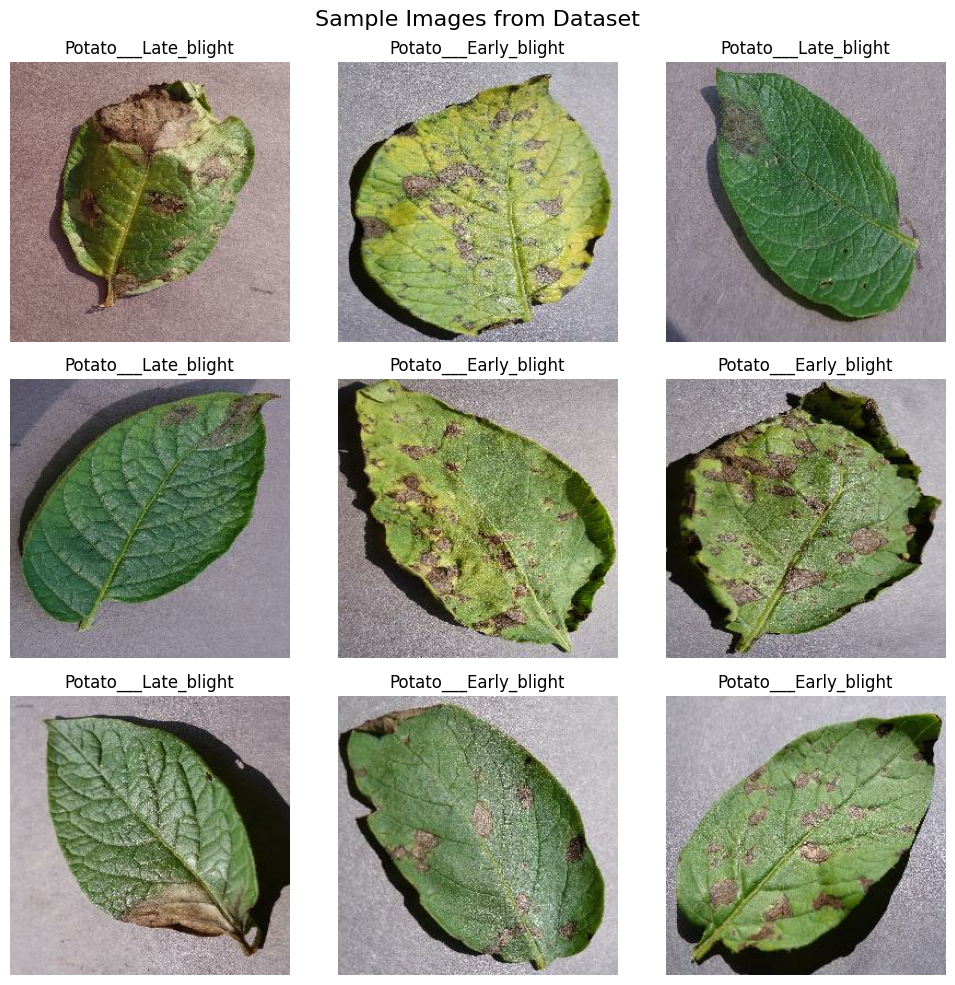

In [11]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(batch_images[i].numpy().astype("uint8"))
    plt.title(class_names[batch_labels[i]])
    plt.axis("off")
plt.suptitle('Sample Images from Dataset', fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
for images, labels in dataset.take(1):
    print(images.shape)

(32, 256, 256, 3)


In [13]:
len(dataset)

68

In [15]:
from PIL import Image
import os

data_dir = '/content/drive/MyDrive/potato_disease_classification'
bad_images = []

for category in os.listdir(data_dir):

    path = os.path.join(data_dir, category)

    for file in os.listdir(path):

        try:
            img = Image.open(os.path.join(path,file))
        except:
            bad_images.append(file)

print("Corrupted images:", len(bad_images))

Corrupted images: 0


In [16]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(256,256),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(256,256),
    batch_size=32
)

Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.


In [17]:
class_names = train_ds.class_names
print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [18]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [19]:
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [20]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.2),

    tf.keras.layers.RandomZoom(0.2),
])

In [21]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [22]:
for images, labels in train_ds.take(1):

    print(images.shape)
    print(labels.shape)

(32, 256, 256, 3)
(32,)


In [23]:
from tensorflow.keras import layers, models

In [24]:
IMG_SIZE = 256
CHANNELS = 3

In [25]:
model = models.Sequential([

    data_augmentation,

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,CHANNELS)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(3,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 335s 6s/step - accuracy: 0.5449 - loss: 0.8815 - val_accuracy: 0.7930 - val_loss: 0.5007
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 377s 6s/step - accuracy: 0.8040 - loss: 0.4810 - val_accuracy: 0.8302 - val_loss: 0.4647
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 372s 6s/step - accuracy: 0.8466 - loss: 0.3781 - val_accuracy: 0.8744 - val_loss: 0.2935
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 328s 6s/step - accuracy: 0.8896 - loss: 0.2848 - val_accuracy: 0.9279 - val_loss: 0.1931
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 330s 6s/step - accuracy: 0.9051 - loss: 0.2640 - val_accuracy: 0.7442 - val_loss: 0.4532
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 322s 6s/step - accuracy: 0.9146 - loss: 0.1990 - val_accuracy: 0.9047 - val_loss: 0.2201
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 376s 6s/step - accuracy: 0.9229 - loss: 0.2177 - val_accuracy: 0.9047 - val_loss: 0.2241
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 337s 6s/step - accuracy: 0.9453 - loss: 0.1612 - val_accuracy: 0.8628 - v

In [29]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

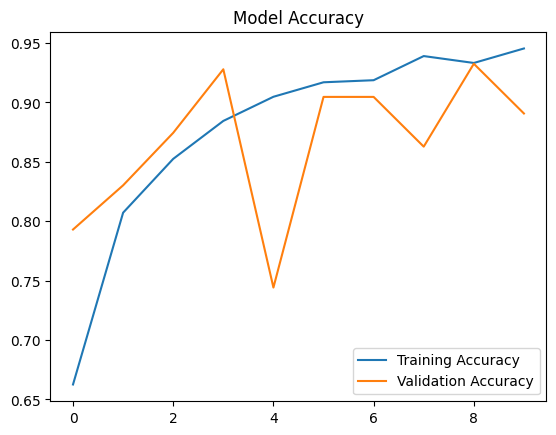

In [30]:
plt.plot(acc,label="Training Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.legend()
plt.title("Model Accuracy")
plt.show()

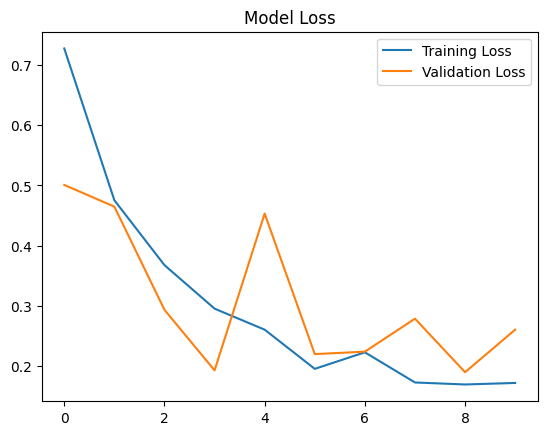

In [31]:
plt.plot(loss,label="Training Loss")
plt.plot(val_loss,label="Validation Loss")
plt.legend()
plt.title("Model Loss")
plt.show()

In [32]:
model.save("models/potato_disease_model.h5")

In [33]:
from google.colab import files

# Ensure the 'models' directory exists if it's the first time saving
import os
if not os.path.exists('models'):
    os.makedirs('models')

# Save the model if it hasn't been saved yet (or to overwrite)
# Note: This line is technically redundant if Emj8Tid_TqMD has already executed successfully,
# but it ensures the file exists before attempting to download.
model.save("models/potato_disease_model.h5")

# Download the model file
files.download("models/potato_disease_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.8790 - loss: 0.2919
Validation Accuracy: 89.07%


In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Gather all validation labels and predictions
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred = np.concatenate([np.argmax(model.predict(x), axis=1) for x, y in val_ds], axis=0)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Detailed report
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
Confusion Matrix:
 [[202   2   0]
 [ 20 157  20]
 [  3   2  24]]
                       precision    recall  f1-score   support

Potato___Early_blight       0.90      0.99      0.94       204
 Potato___Late_blight       0.98      0.80      0.88       197
     Potato___healthy       0.55      0.83      0.66        29

             accuracy                           0.89       430
            macro avg       0.81      0.87      0.83       430
         weighted avg       0.91      0.89      

In [36]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

IMG_SIZE = 224  # MobileNetV2 default

base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                         include_top=False,
                         weights='imagenet')

base_model.trainable = False  # Freeze base layers

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [37]:
model_tl = models.Sequential([
    layers.Resizing(IMG_SIZE, IMG_SIZE),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

In [38]:
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.4799 - loss: 1.0171 - val_accuracy: 0.4581 - val_loss: 0.9148
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.4677 - loss: 1.0277 - val_accuracy: 0.4581 - val_loss: 0.9354
Epoch 3/10
15/54 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.4697 - loss: 0.9638

In [ ]:
base_model.trainable = True

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model_tl.fit(train_ds,
                                validation_data=val_ds,
                                epochs=5)

In [ ]:
model_tl.save("models/potato_disease_model_tl.h5")

In [ ]:
predict_image("data/potato/Potato___Early_blight/sample1.jpg")